# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix



#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [6]:
# Cargamos el primer set de datos
data1 = loadmat('data/ejer_1_data1.mat')
data1


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

#### 3. Create a DataFrame with the features and target

In [28]:
# Los datos vienen en un diccionario. Extraemos X (puntos) y y (clase/etiqueta)
# Esto cómo lo sabe?? 
X = data1['X']
y = data1['y'].ravel() # .ravel() lo deja en el formato que le gusta a sklearn ¿y esto, qué leches es?
#y = data1['y'] - haciéndolo así da error el plot. Ni idea de por qué

#### 4. Plot a scatterplot with the data

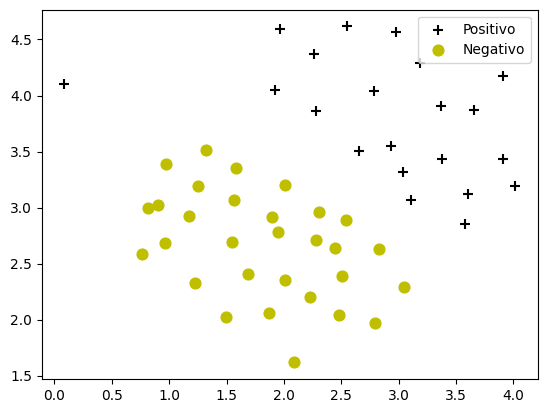

In [ ]:
# Esto dice la IA, yo no entiendo nada. 
def plot_data(X, y):
    # pero qué me narras de puntos positivos y negativos??? cómo tengo  que saber que  esto va de puntos positivos y negativos?
    # Separamos los puntos positivos (1) de los negativos (0)
    pos = (y == 1)
    neg = (y == 0)
    
    plt.scatter(X[pos, 0], X[pos, 1], marker='+', c='k', s=60, label='Positivo')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', c='y', s=60, label='Negativo')
    plt.legend()

plot_data(X, y)
plt.show()


<Axes: >

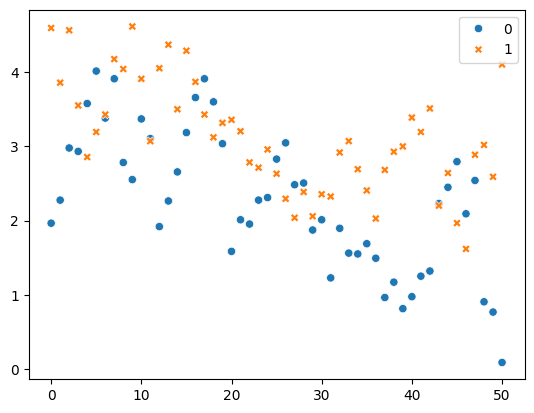

In [38]:
# Esto hubiera hecho yo
sns.scatterplot (X)

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [11]:
svc1 = LinearSVC (C=1, loss='hinge', max_iter=10000)


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [15]:
svc1.fit(X, y)
print(f"Score con C=1: {svc1.score(X, y)}")


Score con C=1: 0.9803921568627451


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [ ]:
# He probado valores a mano. El mínimo para el que el score es 1 es 25
svc100 = SVC(C=25, kernel='linear')
svc100.fit(X, y)
print(f"Score con C=100: {svc100.score(X, y)}")

Score con C=100: 1.0


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

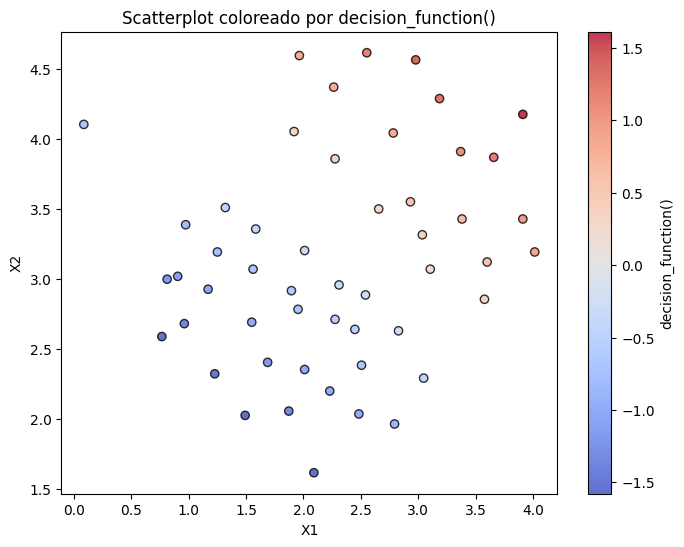

In [ ]:
# Obtener decision_function() para el primer modelo
decision_values = svc1.decision_function(X)

# Scatterplot con X1, X2 y colores según decision_function() - OBVIAMENTE, copy paste de IA porque absolutamente ni idea
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X[:, 0],   # X1
    X[:, 1],   # X2
    c=decision_values,
    cmap='coolwarm',
    edgecolors='k',
    alpha=0.8
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Scatterplot coloreado por decision_function()")
plt.colorbar(scatter, label="decision_function()")
plt.show()

#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

#### 1. Load the data `ejer_1_data2.mat`

In [33]:
data2 = loadmat('data/ejer_1_data2.mat')
data2


{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:54 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0.107143 , 0.60307  ],
        [0.093318 , 0.649854 ],
        [0.0979263, 0.705409 ],
        ...,
        [0.975806 , 0.439474 ],
        [0.989631 , 0.425439 ],
        [0.996544 , 0.414912 ]], shape=(863, 2)),
 'y': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
    

#### 2. Create a DataFrame with the features and target

In [32]:
X2 = data2['X']
y2 = data2['y'].ravel()



#### 3. Plot a scatterplot with the data

<Axes: >

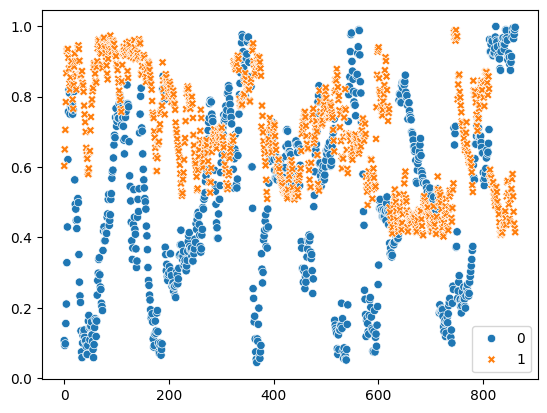

In [35]:
import seaborn as sns
sns.scatterplot (X2)

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [ ]:
# Dice arriba que usemos kernel RBF
svc_rbf = SVC(C=100, gamma=10, kernel='rbf', probability=True)


#### 5. Fit the classifier and get the score

In [40]:
svc_rbf.fit(X2, y2)

print(f"Score en Data 2: {svc_rbf.score(X2, y2)}")

Score en Data 2: 0.9698725376593279


#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

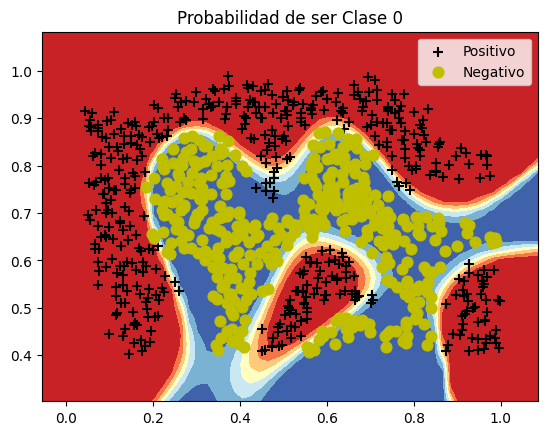

In [41]:
# Creamos una rejilla de puntos para pintar el fondo
h = .02 
x_min, x_max = X2[:, 0].min() - 0.1, X2[:, 0].max() + 0.1
y_min, y_max = X2[:, 1].min() - 0.1, X2[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecimos la probabilidad para cada punto de la rejilla
Z = svc_rbf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 0]
Z = Z.reshape(xx.shape)

# Dibujamos
plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu) # Mapa de color secuencial
plot_data(X2, y2)
plt.title("Probabilidad de ser Clase 0")
plt.show()